In [1]:
import re
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
text = (
  "The small spring starts high in the mountains. "
  "Clear water flows down over the cold stones. "
  "It gains speed as it moves through the valley. "
  "Small streams join together to form a wide river. "
  "The river carries nutrients to the green forest. "
  "Fish swim through the cool and deep water. "
  "Plants grow along the muddy banks of the stream. "
  "The sun warms the surface during the day. "
  "The water finally reaches the blue ocean. "
  "Nature continues this cycle every single year. "
)


# basic word-level tokenizer
def tokenize(text):
    return re.findall(r'\w+', text.lower())


vocab = {"<PAD>": 0, "<UNK>": 1}
for word in tokenize(text):
    if word not in vocab:
        vocab[word] = len(vocab)

vocab

{'<PAD>': 0,
 '<UNK>': 1,
 'the': 2,
 'small': 3,
 'spring': 4,
 'starts': 5,
 'high': 6,
 'in': 7,
 'mountains': 8,
 'clear': 9,
 'water': 10,
 'flows': 11,
 'down': 12,
 'over': 13,
 'cold': 14,
 'stones': 15,
 'it': 16,
 'gains': 17,
 'speed': 18,
 'as': 19,
 'moves': 20,
 'through': 21,
 'valley': 22,
 'streams': 23,
 'join': 24,
 'together': 25,
 'to': 26,
 'form': 27,
 'a': 28,
 'wide': 29,
 'river': 30,
 'carries': 31,
 'nutrients': 32,
 'green': 33,
 'forest': 34,
 'fish': 35,
 'swim': 36,
 'cool': 37,
 'and': 38,
 'deep': 39,
 'plants': 40,
 'grow': 41,
 'along': 42,
 'muddy': 43,
 'banks': 44,
 'of': 45,
 'stream': 46,
 'sun': 47,
 'warms': 48,
 'surface': 49,
 'during': 50,
 'day': 51,
 'finally': 52,
 'reaches': 53,
 'blue': 54,
 'ocean': 55,
 'nature': 56,
 'continues': 57,
 'this': 58,
 'cycle': 59,
 'every': 60,
 'single': 61,
 'year': 62}

In [3]:
tokens = tokenize(text)
token_ids = [vocab.get(word, vocab["<UNK>"]) for word in tokens]
token_tensor = torch.tensor(token_ids, dtype=torch.long)
token_tensor

tensor([ 2,  3,  4,  5,  6,  7,  2,  8,  9, 10, 11, 12, 13,  2, 14, 15, 16, 17,
        18, 19, 16, 20, 21,  2, 22,  3, 23, 24, 25, 26, 27, 28, 29, 30,  2, 30,
        31, 32, 26,  2, 33, 34, 35, 36, 21,  2, 37, 38, 39, 10, 40, 41, 42,  2,
        43, 44, 45,  2, 46,  2, 47, 48,  2, 49, 50,  2, 51,  2, 10, 52, 53,  2,
        54, 55, 56, 57, 58, 59, 60, 61, 62])

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vocab_size = len(vocab)

d_model = 512
num_of_heads = 4
d_k = d_v = 128       # d_model / num_of_heads
d_ff = 2048


class PositionalEncoding(nn.Module):
    def __init__(self, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        seq_len = x.size(0)
        x = x + self.pe[0, :seq_len, :]
        return self.dropout(x)

class Attention(nn.Module):

  def __init__(self):
    super().__init__()

    # xavier initialization: scale by 1/sqrt(d_model) to keep dot products in range
    scale = 1.0 / math.sqrt(d_model)
    self.W_q = nn.Parameter(torch.randn(d_model, d_k) * scale)
    self.W_k = nn.Parameter(torch.randn(d_model, d_k) * scale)
    self.W_v = nn.Parameter(torch.randn(d_model, d_k) * scale)
    self.softmax = nn.Softmax(dim=-1)

  def forward(self, X: torch.Tensor) -> torch.Tensor:
    Q, K, V = X @ self.W_q, X @ self.W_k, X @ self.W_v      # N x 128 each
    return self.attention(Q, K, V, d_k=self.W_q.size(1))

  def attention(self, Q: torch.Tensor, K: torch.Tensor, V: torch.Tensor, d_k = None):
      attn_weights = self.softmax((Q @ K.T) / math.sqrt(d_k))
      context = attn_weights @ V
      return context, attn_weights


class MultiHeadAttention(nn.Module):

  def __init__(self):
    super().__init__()
    self.heads = nn.ModuleList([Attention() for _ in range(num_of_heads)])
    self.W_o = nn.Linear(d_model, d_model)

  def forward(self, X: torch.Tensor):
    contexts = []
    all_attn_weights = []

    for head in self.heads:
        context, attn_weights = head(X)
        contexts.append(context)
        all_attn_weights.append(attn_weights)

    # concatenate 4 matrices of (N x 128) into 1 matrix of (N x 512)
    combined = torch.cat(contexts, dim=-1)
    stacked_weights = torch.stack(all_attn_weights, dim=0)

    # final linear projection
    output = self.W_o(combined)     # (N x 512) @ (512 x 512) == (N x 512)

    return output, stacked_weights


class LayerNorm(nn.Module):
    def __init__(self, d_model=512, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_normalized = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_normalized + self.beta


class FFN(nn.Module):

  def __init__(self):
    super().__init__()
    self.input2hidden = nn.Linear(d_model, d_ff)        # 512 x 2048
    self.gelu = nn.GELU()
    self.hidden2output = nn.Linear(d_ff, d_model)       # 2048 x 512

  def forward(self, X: torch.Tensor):
    hidden = self.gelu(self.input2hidden(X))            # N x 2048
    return self.hidden2output(hidden)                   # N x 512


class Encoder(nn.Module):

  def __init__(self):
    super().__init__()

    self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=d_model)
    self.position_encoding = PositionalEncoding()
    self.multi_head_attention = MultiHeadAttention()
    self.layer_norm = LayerNorm()
    self.ffn = FFN()

  def forward(self, tokens: torch.Tensor) -> torch.Tensor:
    # Embeddings
    X = self.embedding(tokens)

    # Sinusoidal PE
    X_pos = self.position_encoding(X)

    # Multi-Head Attention
    multi_head, attn_weights = self.multi_head_attention(X_pos)

    # Add & Norm
    X_new = self.layer_norm.forward(X_pos + multi_head)

    # FFN
    ffn_output = self.ffn.forward(X_new)

    # Add & Norm
    X_new_final = self.layer_norm.forward(X_new + ffn_output)

    return X_new_final, attn_weights

In [5]:
encoder = Encoder()
encoded_sequence, heatmap_data = encoder(token_tensor)

In [10]:
print(token_tensor)

tensor([ 2,  3,  4,  5,  6,  7,  2,  8,  9, 10, 11, 12, 13,  2, 14, 15, 16, 17,
        18, 19, 16, 20, 21,  2, 22,  3, 23, 24, 25, 26, 27, 28, 29, 30,  2, 30,
        31, 32, 26,  2, 33, 34, 35, 36, 21,  2, 37, 38, 39, 10, 40, 41, 42,  2,
        43, 44, 45,  2, 46,  2, 47, 48,  2, 49, 50,  2, 51,  2, 10, 52, 53,  2,
        54, 55, 56, 57, 58, 59, 60, 61, 62])


In [11]:
encoded_sequence[-1]

tensor([-2.3433e+00, -1.3857e+00, -4.5253e-01,  3.1630e-01, -1.0590e+00,
         7.3315e-01, -4.3222e-01, -1.7786e+00, -2.5456e-02,  1.0004e+00,
        -4.8814e-01, -6.0911e-01,  1.6644e+00, -2.4580e-01, -3.5235e+00,
        -8.0018e-02,  6.1547e-01, -2.3585e+00,  3.7959e-01, -5.1369e-01,
        -1.1666e+00, -5.6707e-01,  6.3672e-01, -1.3872e+00,  1.0165e+00,
        -1.3992e-01, -1.3990e-01,  8.2748e-01,  8.7487e-01,  4.1215e-01,
         4.2255e-01, -1.0160e+00, -2.1826e-02, -7.4319e-01, -8.2262e-01,
         1.2479e-01, -5.3773e-01,  1.9133e-01, -8.6166e-01, -1.6025e-01,
         1.1003e+00,  9.7287e-02, -1.1545e-01,  4.0294e-01, -1.9668e+00,
        -4.4332e-01, -7.6994e-01, -2.6647e+00,  9.1214e-01, -2.5507e+00,
        -9.9430e-01,  1.3558e+00, -1.5552e+00,  1.0656e+00, -5.7728e-01,
        -8.8105e-01, -9.2494e-02, -1.0130e+00, -1.2800e-01,  6.4608e-02,
        -4.9202e-01, -1.6735e+00,  3.1481e-02,  1.7006e-02, -3.7581e-02,
        -4.4299e-04, -1.2017e+00,  2.3340e-01,  3.6

In [7]:
encoded_sequence.shape

torch.Size([81, 512])

In [8]:
heatmap_data

tensor([[[0.0215, 0.0003, 0.0074,  ..., 0.0318, 0.0013, 0.0063],
         [0.0408, 0.0086, 0.0056,  ..., 0.0035, 0.0013, 0.0022],
         [0.0043, 0.0059, 0.0003,  ..., 0.0019, 0.0005, 0.0014],
         ...,
         [0.0082, 0.0014, 0.0195,  ..., 0.0081, 0.0012, 0.0005],
         [0.0111, 0.0032, 0.0016,  ..., 0.0177, 0.0005, 0.0021],
         [0.0018, 0.0071, 0.0009,  ..., 0.0078, 0.0036, 0.0092]],

        [[0.0065, 0.0025, 0.0022,  ..., 0.0143, 0.0436, 0.1083],
         [0.0047, 0.0187, 0.0100,  ..., 0.0183, 0.0173, 0.0188],
         [0.0015, 0.0020, 0.0062,  ..., 0.0028, 0.0164, 0.1330],
         ...,
         [0.0248, 0.0054, 0.0225,  ..., 0.0459, 0.0028, 0.0198],
         [0.0153, 0.0008, 0.0286,  ..., 0.0037, 0.0059, 0.0979],
         [0.0102, 0.0022, 0.0066,  ..., 0.0029, 0.0041, 0.0033]],

        [[0.0037, 0.0160, 0.0154,  ..., 0.0001, 0.0070, 0.0118],
         [0.0005, 0.0080, 0.0037,  ..., 0.0636, 0.0054, 0.0200],
         [0.0029, 0.0027, 0.0004,  ..., 0.0005, 0.0019, 0.

=== Input Tokens ===
Tokens:    ['the', 'small', 'spring', 'starts', 'high', 'in', 'the', 'mountains']
Token IDs: [2, 3, 4, 5, 6, 7, 2, 8]



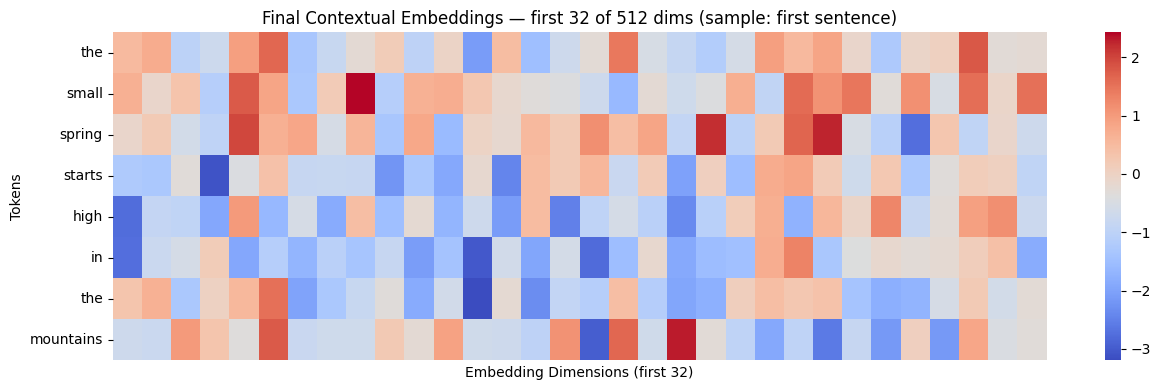

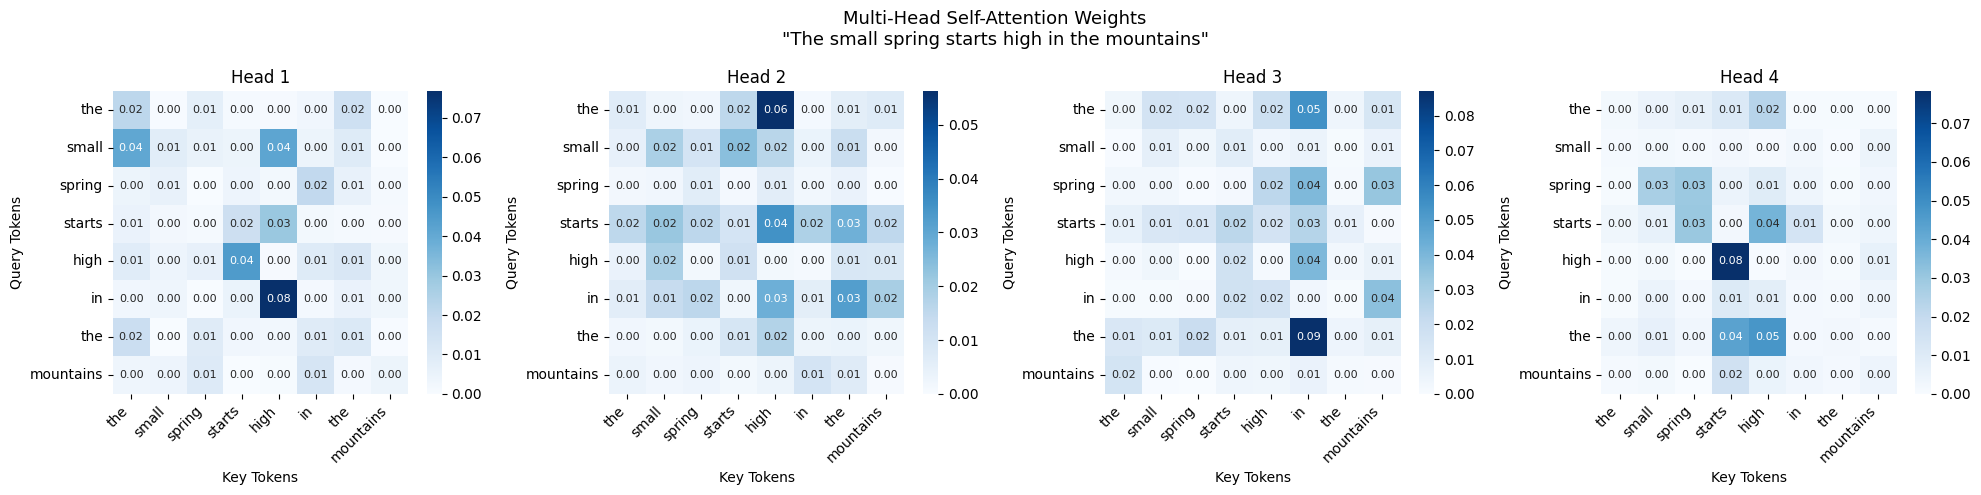

In [ ]:
# Step 5: show input tokens, final contextual embeddings, and attention heatmaps

sample_len = 8
sample_tokens = tokens[:sample_len]
sample_ids = token_ids[:sample_len]

print("=== Input Tokens ===")
print(f"Tokens:    {sample_tokens}")
print(f"Token IDs: {sample_ids}")
print()


fig, ax = plt.subplots(figsize=(13, 4))
embed_sample = encoded_sequence[:sample_len].detach().numpy()[:, :32]
sns.heatmap(
    embed_sample,
    ax=ax,
    cmap='coolwarm',
    xticklabels=False,
    yticklabels=sample_tokens
)
ax.set_title("Final Contextual Embeddings — first 32 of 512 dims (sample: first sentence)")
ax.set_xlabel("Embedding Dimensions (first 32)")
ax.set_ylabel("Tokens")
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()


attn_sample = heatmap_data[:, :sample_len, :sample_len].detach().numpy()

fig, axes = plt.subplots(1, num_of_heads, figsize=(20, 5))
for i, ax in enumerate(axes):
    sns.heatmap(
        attn_sample[i],
        ax=ax,
        cmap='Blues',
        xticklabels=sample_tokens,
        yticklabels=sample_tokens,
        vmin=0, vmax=attn_sample[i].max(),
        annot=True, fmt=".2f", annot_kws={"size": 8}
    )
    ax.set_title(f"Head {i + 1}")
    ax.set_xlabel("Key Tokens")
    ax.set_ylabel("Query Tokens")
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    plt.setp(ax.get_yticklabels(), rotation=0)

plt.suptitle('Multi-Head Self-Attention Weights\n"The small spring starts high in the mountains"', fontsize=13)
plt.tight_layout()
plt.show()

=== Attention Weight Matrix ===
[[0.2069 0.1455 0.2687 0.0995 0.2794]
 [0.0507 0.2036 0.3672 0.2077 0.1708]
 [0.1314 0.078  0.4801 0.0533 0.2572]
 [0.2384 0.173  0.0847 0.2283 0.2757]
 [0.0589 0.5737 0.0283 0.232  0.107 ]]

Row sums (should all be 1.0): [1. 1. 1. 1. 1.]

=== Output Vectors ===
[[ 0.2337  0.1537 -0.9929  0.0103 -0.2313  0.565   0.5892  0.3023]
 [ 0.7965  0.276  -1.1746 -0.0985 -0.161   0.5131  0.5767  0.4047]
 [ 0.7115  0.3849 -1.1326 -0.3435 -0.3326  0.9276  0.6849  0.3331]
 [-0.0327 -0.0793 -1.0354  0.3175 -0.2021  0.1016  0.446   0.3093]
 [ 0.1705  0.0327 -0.6371  0.5708  0.3913  0.0094  0.5202  0.4017]]

=== Softmax Stability Check ===
d_k = 8, sqrt(d_k) = 2.8284

Raw scores   — mean: -0.0484,  std: 2.4117,  max: 6.2623,  min: -4.3360
Scaled scores — mean: -0.0171,  std: 0.8527,  max: 2.2140,  min: -1.5330

Softmax (unscaled) entropy — mean: 0.9033  (lower → more peaked / collapsed)
Softmax (scaled)   entropy — mean: 1.4104  (higher → more spread out)


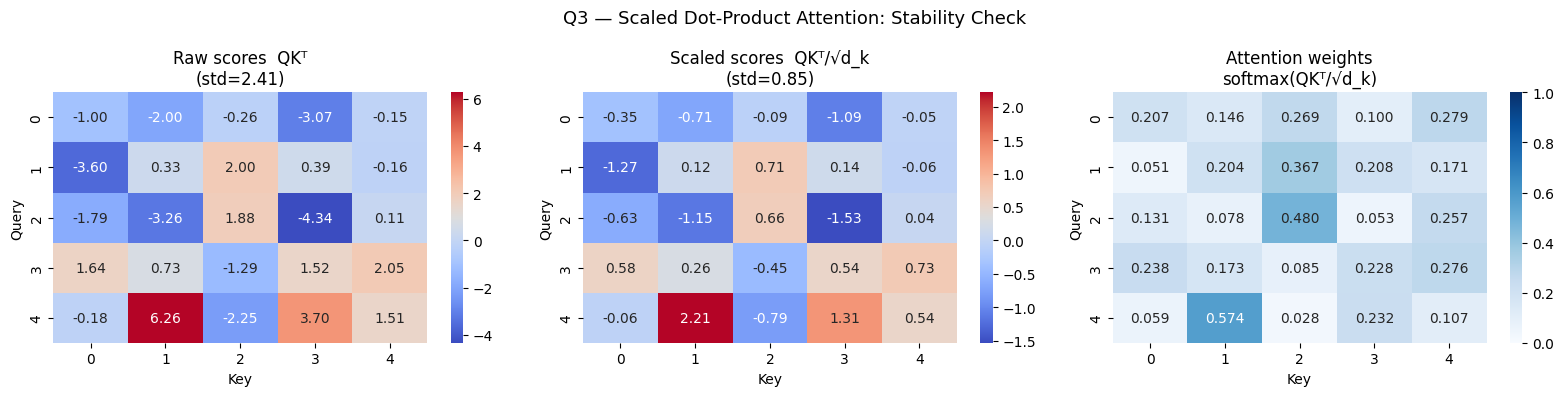

In [12]:
# Q3: Scaled Dot-Product Attention

def scaled_dot_product_attention(Q: torch.Tensor, K: torch.Tensor, V: torch.Tensor):
    d_k = Q.size(-1)
    raw_scores = Q @ K.T
    scaled_scores = raw_scores / math.sqrt(d_k)
    attn_weights = torch.softmax(scaled_scores, dim=-1)
    output = attn_weights @ V
    return attn_weights, output, raw_scores, scaled_scores


torch.manual_seed(42)
seq_len, d_k = 5, 8
Q_test = torch.randn(seq_len, d_k)
K_test = torch.randn(seq_len, d_k)
V_test = torch.randn(seq_len, d_k)
attn_weights, output, raw_scores, scaled_scores = scaled_dot_product_attention(Q_test, K_test, V_test)

print("=== Attention Weight Matrix ===")
print(attn_weights.detach().numpy().round(4))
print(f"\nRow sums (should all be 1.0): {attn_weights.sum(dim=-1).detach().numpy().round(6)}")


print("\n=== Output Vectors ===")
print(output.detach().numpy().round(4))


fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.heatmap(raw_scores.detach().numpy(), ax=axes[0], cmap='coolwarm', annot=True, fmt='.2f')
axes[0].set_title(f"Raw scores  QKᵀ\n(std={raw_scores.std().item():.2f})")
axes[0].set_xlabel("Key"); axes[0].set_ylabel("Query")

sns.heatmap(scaled_scores.detach().numpy(), ax=axes[1], cmap='coolwarm', annot=True, fmt='.2f')
axes[1].set_title(f"Scaled scores  QKᵀ/√d_k\n(std={scaled_scores.std().item():.2f})")
axes[1].set_xlabel("Key"); axes[1].set_ylabel("Query")

sns.heatmap(attn_weights.detach().numpy(), ax=axes[2], cmap='Blues', annot=True, fmt='.3f', vmin=0, vmax=1)
axes[2].set_title("Attention weights\nsoftmax(QKᵀ/√d_k)")
axes[2].set_xlabel("Key"); axes[2].set_ylabel("Query")

plt.suptitle("Q3 — Scaled Dot-Product Attention: Stability Check", fontsize=13)
plt.tight_layout()
plt.show()